In [2]:
import torch
import matplotlib.pyplot as plt
import random
import torch.nn.functional as F
%matplotlib inline

In [3]:
# Reading the data

words = open('names.txt', 'r').read().splitlines()

print(words[:10])
len(words)

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']


32033

In [4]:
# sorted(b.items(), key=lambda kv: -kv[1])

In [5]:
a = torch.zeros((27, 27), dtype=torch.int32)

In [6]:
chars = sorted(list(set(''.join(words))))

In [7]:
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
sorted(stoi)

['.',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [8]:
# Making a simple biagram model

b = {}
for w in words:
    hal = ['.'] + list(w) + ['.']
    for a1, a2 in zip(hal, hal[1:]):
        ix1 = stoi[a1]
        ix2 = stoi[a2]
        a[ix1][ix2] +=1
        bigram = a1+a2
        b[bigram] = b.get(bigram, 0) + 1

In [9]:
# Example cell

type(a[3,3].item())

int

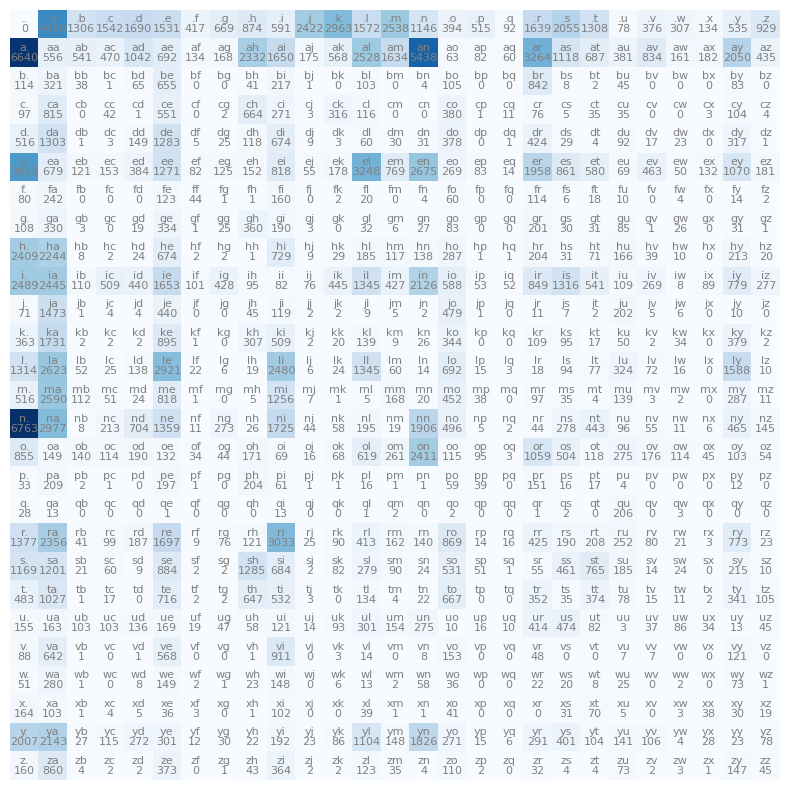

In [10]:
# Visaual representation of the word vector plotting

# plt.imshow(a)

# plt.figure(figsize=(20, 20))
# plt.imshow(a, cmap="Blues")
# for i in range(28):
#     for j in range(28):
#         chstr = itos[i] + itos[j]
#         plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
#         plt.text(j, i, a[i, j].item(), ha="center", va="bottom", color="gray")

# plt.axis("off")

plt.figure(figsize=(10,10))
plt.imshow(a, cmap="Blues")

for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        # Label 1: The characters (shifted slightly up)
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray", fontsize=8)
        # Label 2: The value (shifted slightly down)
        plt.text(j, i, a[i, j].item(), ha="center", va="top", color="gray", fontsize=8)

plt.axis("off")
plt.show()

<BarContainer object of 27 artists>

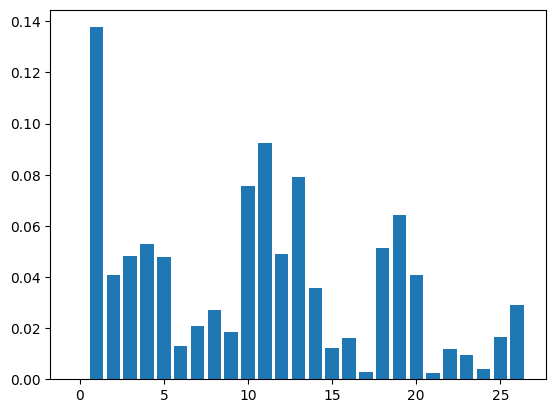

In [51]:
# a[0, :]
p = a[0].float() #Type convert to float
p /= p.sum()
plt.bar(torch.arange(27), p)

In [60]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

'c'

In [13]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p/p.sum()

In [14]:
x = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
type(x)
# Dice roll

int

tensor([[32033, 33885,  2645,  3532,  5496, 20423,   905,  1927,  7616, 17701,
          2900,  5040, 13958,  6642, 18327,  7934,  1026,   272, 12700,  8106,
          5570,  3135,  2573,   929,   697,  9776,  2398]])


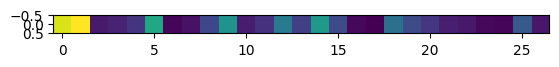

In [15]:
print(a.sum(0, keepdim=True))
plt.imshow(a.sum(0, keepdim=True))

In [16]:
P = a.float()
P.sum(1, keepdim=True).size()

torch.Size([27, 1])

In [111]:
P = (a+1).float()
P = P / P.sum(1, keepdim=True)

In [112]:
P[0].sum()

tensor(1.)

In [222]:
seeder = random.randint(0, 9999999999)
g = torch.Generator().manual_seed(seeder)

for _ in range(10):
    out = []
    ix = 0
    while True:
        # p = P[ix]
        p = a[ix].float()
        p = p/p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print("".join(out))


tzesama.
wnoy.
jonais.
ma.
fi.
jaymaray.
caokh.
a.
a.
mar.


In [119]:
likelehood = 0.0
i=0
# for w in words[:10]:
for w in "shaurya":
    i+=1
    hal = ['.'] + list(w) + ['.']
    for a1, a2 in zip(hal, hal[1:]):
        ix1 = stoi[a1]
        ix2 = stoi[a2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        likelehood+=logprob
        print(f"{a1},{a2}:\t{-1*logprob:.4} \t {prob:.4f}")

print(f"\nLikeyhood: {likelehood.item()*-1}")

print(f"\nAverage Likeloeyhood: {(likelehood.item()*-1)/i}")

# In log likelihood, lower score is considered better. 

.,s:	2.747 	 0.0641
s,.:	1.939 	 0.1439
.,h:	3.601 	 0.0273
h,.:	1.154 	 0.3153
.,a:	1.984 	 0.1376
a,.:	1.631 	 0.1958
.,u:	6.006 	 0.0025
u,.:	3.009 	 0.0493
.,r:	2.973 	 0.0512
r,.:	2.223 	 0.1083
.,y:	4.091 	 0.0167
y,.:	1.586 	 0.2048
.,a:	1.984 	 0.1376
a,.:	1.631 	 0.1958

Likeyhood: 36.55691146850586

Average Likeloeyhood: 5.222415924072266


In [120]:
# Traning and testing split

xs, ys = [], []

for w in words[:1]:
    hal = ['.'] + list(w) + ['.']
    for a1, a2 in zip(hal, hal[1:]):
        ix1 = stoi[a1]
        ix2 = stoi[a2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

xs

tensor([ 0,  5, 13, 13,  1])

In [22]:
ys

tensor([ 5, 13, 13,  1,  0])

In [126]:
x_enc = F.one_hot(xs, num_classes=27).float()
y_enc = F.one_hot(ys, num_classes=27).float()
print(x_enc)
print(x_enc.dtype)

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])
torch.float32


In [127]:
W = torch.rand(27,27)
W_xenc = x_enc @ W
W_xenc.shape
#logits

torch.Size([5, 27])

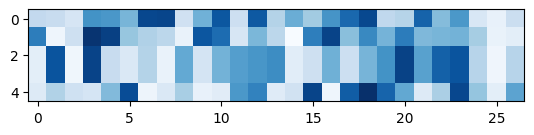

In [104]:
counts = W_xenc.exp()
# counts
plt.imshow(counts, cmap="Blues")
# 

In [26]:
counts = counts/ counts.sum(1, keepdim=True)
counts

tensor([[0.0293, 0.0287, 0.0262, 0.0416, 0.0410, 0.0365, 0.0515, 0.0518, 0.0272,
         0.0371, 0.0495, 0.0278, 0.0493, 0.0310, 0.0376, 0.0328, 0.0414, 0.0472,
         0.0513, 0.0297, 0.0307, 0.0479, 0.0354, 0.0408, 0.0258, 0.0229, 0.0280],
        [0.0458, 0.0226, 0.0283, 0.0557, 0.0540, 0.0349, 0.0323, 0.0309, 0.0234,
         0.0511, 0.0481, 0.0266, 0.0372, 0.0309, 0.0211, 0.0457, 0.0536, 0.0360,
         0.0442, 0.0378, 0.0459, 0.0370, 0.0375, 0.0379, 0.0334, 0.0235, 0.0246],
        [0.0252, 0.0527, 0.0229, 0.0549, 0.0302, 0.0269, 0.0327, 0.0240, 0.0403,
         0.0280, 0.0388, 0.0420, 0.0433, 0.0448, 0.0255, 0.0290, 0.0393, 0.0294,
         0.0386, 0.0440, 0.0551, 0.0417, 0.0508, 0.0527, 0.0322, 0.0230, 0.0322],
        [0.0252, 0.0527, 0.0229, 0.0549, 0.0302, 0.0269, 0.0327, 0.0240, 0.0403,
         0.0280, 0.0388, 0.0420, 0.0433, 0.0448, 0.0255, 0.0290, 0.0393, 0.0294,
         0.0386, 0.0440, 0.0551, 0.0417, 0.0508, 0.0527, 0.0322, 0.0230, 0.0322],
        [0.0269, 0.0336,

<h2> Overall Recreation of what is made so far</h2>

In [27]:
xs

tensor([ 0,  5, 13, 13,  1])

In [28]:
ys

tensor([ 5, 13, 13,  1,  0])

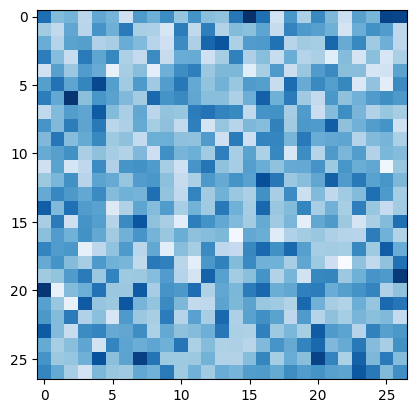

In [129]:
# Randomly initialise 27 neurons and put random weights and each neuron gets 27 inputs. The seeding allows the randomness to be static while multiple processing

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g)
plt.imshow(W, cmap="Blues")

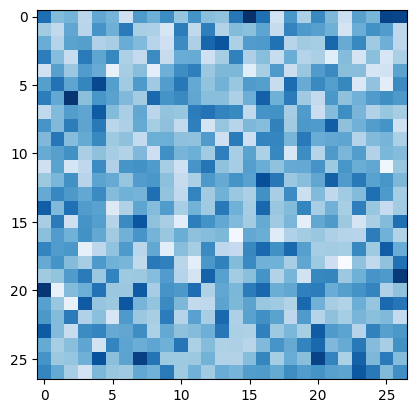

In [43]:
plt.imshow(W, cmap="Blues")

In [30]:
xenc = F.one_hot(xs,num_classes=27).float()     #One hot encoding data of the train data
logits = xenc @ W                               #Vector multipication
counts = logits.exp()                           #Exponentiating the input
probs = counts / counts.sum(1, keepdim=True)    #Normalising the probablity

# Last two lines together are called softmax

In [136]:
# plt.imshow(counts, cmap="Blues")
counts

tensor([[1.4397, 1.4100, 1.2858, 2.0443, 2.0148, 1.7915, 2.5301, 2.5444, 1.3334,
         1.8229, 2.4300, 1.3646, 2.4195, 1.5230, 1.8448, 1.6103, 2.0343, 2.3199,
         2.5208, 1.4563, 1.5064, 2.3535, 1.7380, 2.0038, 1.2671, 1.1236, 1.3740],
        [2.1850, 1.0791, 1.3489, 2.6554, 2.5745, 1.6622, 1.5402, 1.4721, 1.1172,
         2.4350, 2.2910, 1.2692, 1.7741, 1.4745, 1.0055, 2.1767, 2.5553, 1.7153,
         2.1084, 1.8007, 2.1865, 1.7632, 1.7866, 1.8083, 1.5927, 1.1227, 1.1733],
        [1.1737, 2.4525, 1.0660, 2.5552, 1.4084, 1.2519, 1.5215, 1.1198, 1.8780,
         1.3033, 1.8085, 1.9565, 2.0186, 2.0847, 1.1860, 1.3486, 1.8313, 1.3687,
         1.7967, 2.0468, 2.5641, 1.9399, 2.3653, 2.4527, 1.4979, 1.0720, 1.4980],
        [1.1737, 2.4525, 1.0660, 2.5552, 1.4084, 1.2519, 1.5215, 1.1198, 1.8780,
         1.3033, 1.8085, 1.9565, 2.0186, 2.0847, 1.1860, 1.3486, 1.8313, 1.3687,
         1.7967, 2.0468, 2.5641, 1.9399, 2.3653, 2.4527, 1.4979, 1.0720, 1.4980],
        [1.2276, 1.5325,

<h1>New Summary of the Language Model</h1>

In [202]:
# Create the dataset

xs, ys = [], []

for w in words:
    hal = ['.'] + list(w) + ['.']
    for a1, a2 in zip(hal, hal[1:]):
        ix1 = stoi[a1]
        ix2 = stoi[a2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

num = xs.nelement()
print(f"Number of data points: {num}")

Number of data points: 228146


In [203]:
# Initalising the nn

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g, requires_grad=True)

In [212]:
(W**2).sum()

tensor(1137.9506, grad_fn=<SumBackward0>)

In [213]:
# gradient descent

for k in range(100):

    # forward pass
    xenc = F.one_hot(xs, num_classes=27).float()  #One hot
    logits = xenc @ W                                               #Vector multipication
    counts = logits.exp()                                           #Exponentiating the input
    probs = counts / counts.sum(1, keepdim=True)                    #Normalising the probablity
    loss  = -probs[torch.arange(num), ys].log().mean() + 0.01 * (W**2).mean()         #Negative log likelihood loss
    print(f"Step {k}: {loss.item():.4f}")

    # backward pass
    W.grad = None
    loss.backward()

    # update weights
    with torch.no_grad():
        W -= 20 * W.grad

Step 0: 2.4941
Step 1: 2.4940
Step 2: 2.4939
Step 3: 2.4937
Step 4: 2.4936
Step 5: 2.4935
Step 6: 2.4934
Step 7: 2.4933
Step 8: 2.4932
Step 9: 2.4931
Step 10: 2.4931
Step 11: 2.4930
Step 12: 2.4929
Step 13: 2.4928
Step 14: 2.4927
Step 15: 2.4926
Step 16: 2.4925
Step 17: 2.4924
Step 18: 2.4923
Step 19: 2.4922
Step 20: 2.4921
Step 21: 2.4921
Step 22: 2.4920
Step 23: 2.4919
Step 24: 2.4918
Step 25: 2.4917
Step 26: 2.4917
Step 27: 2.4916
Step 28: 2.4915
Step 29: 2.4914
Step 30: 2.4913
Step 31: 2.4913
Step 32: 2.4912
Step 33: 2.4911
Step 34: 2.4910
Step 35: 2.4910
Step 36: 2.4909
Step 37: 2.4908
Step 38: 2.4907
Step 39: 2.4907
Step 40: 2.4906
Step 41: 2.4905
Step 42: 2.4905
Step 43: 2.4904
Step 44: 2.4903
Step 45: 2.4903
Step 46: 2.4902
Step 47: 2.4901
Step 48: 2.4901
Step 49: 2.4900
Step 50: 2.4899
Step 51: 2.4899
Step 52: 2.4898
Step 53: 2.4898
Step 54: 2.4897
Step 55: 2.4896
Step 56: 2.4896
Step 57: 2.4895
Step 58: 2.4895
Step 59: 2.4894
Step 60: 2.4893
Step 61: 2.4893
Step 62: 2.4892
St

In [223]:
# Sampling from the model

g = torch.Generator().manual_seed(seeder)

for i in range(10):
    out = []
    ix = 0
    while True:
        p = (W[ix].exp() / W[ix].exp().sum()).detach() #Softmax
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print("".join(out))

tzviama.
wnofbronais.
ma.
fi.
jaymaray.
caokh.
a.
a.
mar.
s.


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(torch.__version__)

Using device: cuda
2.6.0+cu124
